In [1]:
print(2)

2


In [9]:
import sim_modules as MS
import matplotlib.pyplot as plt
from importlib import reload

In [19]:
reload(MS)
config = MS.SimulationConfig(
    L_col=200,
    L_row=200,
    D=1,
    gamma=0.1,
    alpha=0.01,
    T=10_000_000,
    track_every=10000,
    seed=235235,
    progress=True,
    p=0.6,
    populate_first_100 = True,
)

In [13]:
reload(MS)
results = config.run_main()

Simulation:   0%|          | 0/1000000 [00:00<?, ?time unit/s]

Simulation: 100%|██████████| 1000000/1000000 [11:31<00:00, 1445.98time unit/s]


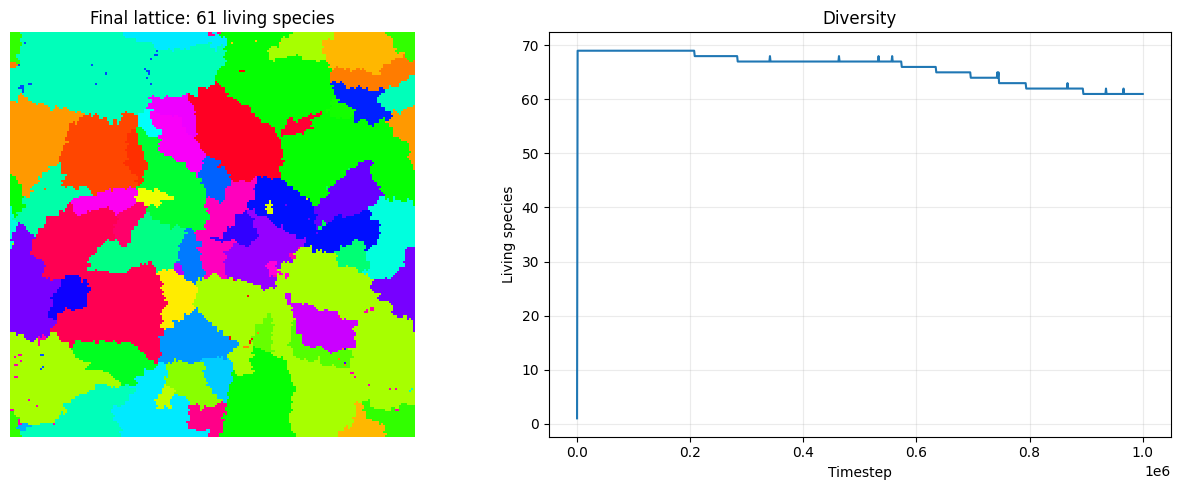

Living species:       61
Largest species ID:   184
Introduced during run: 183


In [14]:
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

def show_results(results):
    lattice = results["lattice"]
    species_ids = np.unique(lattice[lattice > 0])
    number_of_species = species_ids.size

    # Compact historical IDs so every currently living species gets a color.
    display_lattice = np.ones(lattice.shape, dtype=np.int32)  # Empty = 1
    display_lattice[lattice == -1] = 0                       # Blocked = 0
    occupied = lattice > 0
    display_lattice[occupied] = (
        np.searchsorted(species_ids, lattice[occupied]) + 2
    )

    hues = (np.arange(max(number_of_species, 1)) * 0.61803398875) % 1
    species_colors = plt.colormaps["hsv"](hues)
    colors = np.vstack(([0, 0, 0, 1], [0.92, 0.92, 0.92, 1], species_colors))
    colors = colors[:number_of_species + 2]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(number_of_species + 3) - 0.5, cmap.N)

    fig, (ax_lattice, ax_diversity) = plt.subplots(1, 2, figsize=(13, 5))
    ax_lattice.imshow(
        display_lattice, cmap=cmap, norm=norm, interpolation="nearest"
    )
    ax_lattice.set_title(f"Final lattice: {number_of_species:,} living species")
    ax_lattice.set_axis_off()

    ax_diversity.plot(
        results["tracked_timesteps"], results["diversity_history"], lw=1.5
    )
    ax_diversity.set(xlabel="Timestep", ylabel="Living species", title="Diversity")
    ax_diversity.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Living species:       {results['diversity']:,}")
    print(f"Largest species ID:   {results['newest_species']:,}")
    print(f"Introduced during run: {results['newest_species'] - config.D:,}")

show_results(results)

In [4]:
reload(MS)
config.gamma = 0.1
results_low_div = config.run_main()

c:\Users\t1admluqv\Desktop\VoyageOptimization\Seasonality_Luc\Current_Simulation\SPvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Simulation: 100%|██████████| 2000000/2000000 [16:42<00:00, 1995.70time unit/s]


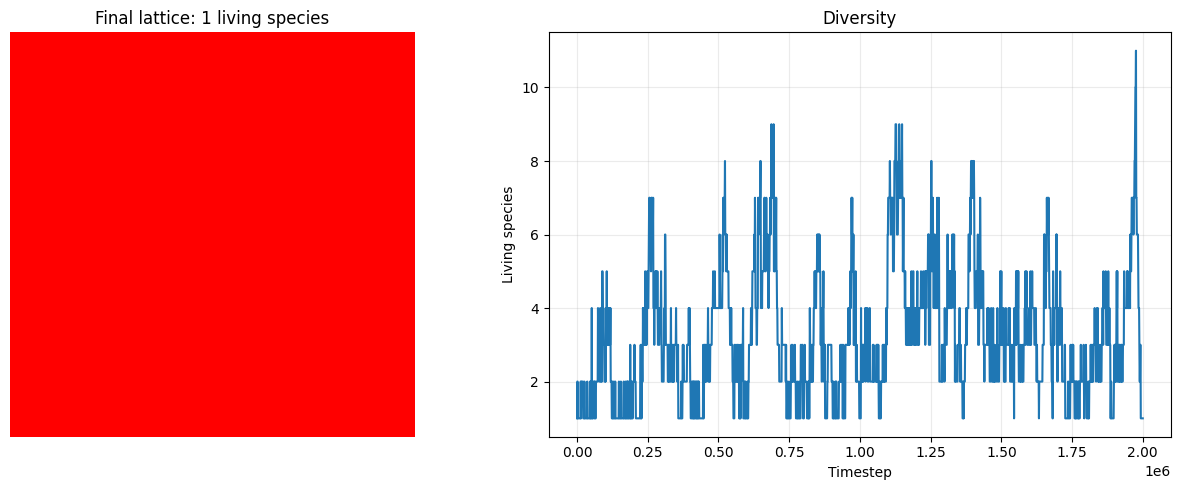

Living species:       1
Largest species ID:   1,942
Introduced during run: 1,941


In [6]:
show_results(results_low_div)

In [7]:
reload(MS)
config.p = 0.2
results_perc = config.run_percolation()

Simulation: 100%|██████████| 2000000/2000000 [23:53<00:00, 1395.06time unit/s]


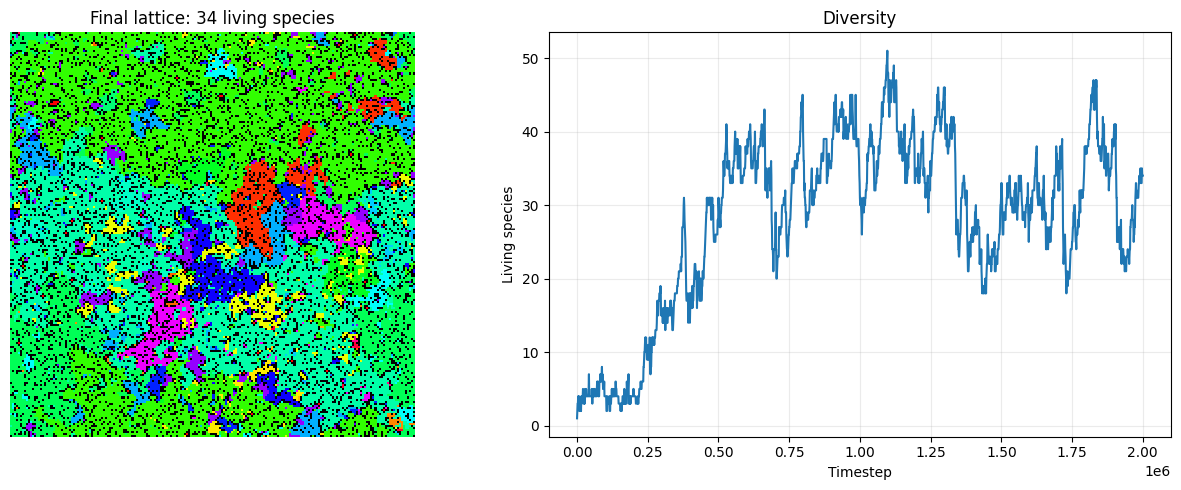

Living species:       34
Largest species ID:   1,988
Introduced during run: 1,987


In [8]:
# Run after results_perc = config.run_percolation()
show_results(results_perc)

In [ ]:
reload(MS)
config.p = 0.6
results_perc = config.run_percolation()

Simulation:  45%|████▍     | 4490000/10000000 [1:00:31<1:26:42, 1059.16time unit/s]

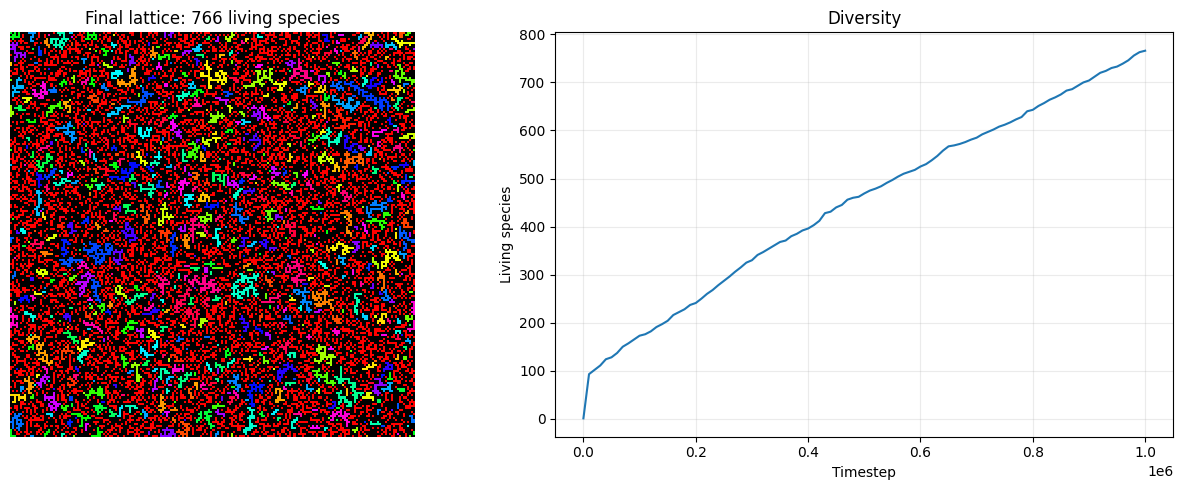

Living species:       766
Largest species ID:   1,102
Introduced during run: 1,101


In [18]:
# Run after results_perc = config.run_percolation()
show_results(results_perc)